<a href="https://colab.research.google.com/github/Zahraalavi2415/Zahraalavi2415.github.io/blob/main/Copy_of_A_Monte_Carlo_approach_to_value_of_information_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_5399/823940769.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(unnorm, x_grid)
/tmp/ipykernel_5399/823940769.py:144: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  enpv_develop = np.trapz(npv_vals * posterior_pdf, x_grid)


RESULTS
EMV(go now)             = 33.559
Best decision now       = develop
EMV(perfect info)       = 41.478
VOPI                    = 7.919
EMV(imperfect info)     = 39.102
VOI(imperfect)          = 5.543

For observation y = 156.0:
ENPV(develop | y=156)   = 48.381
Best action             = develop


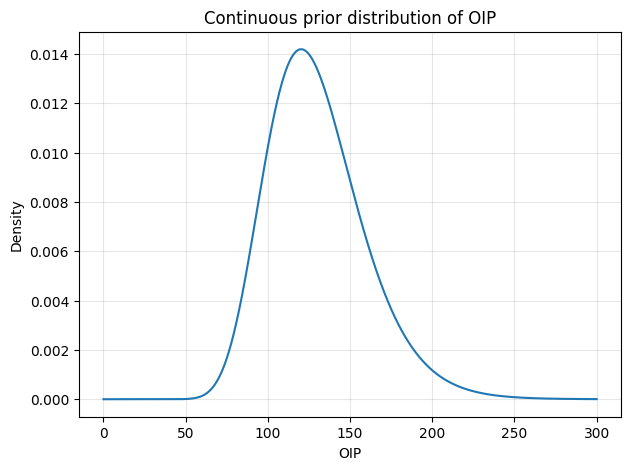

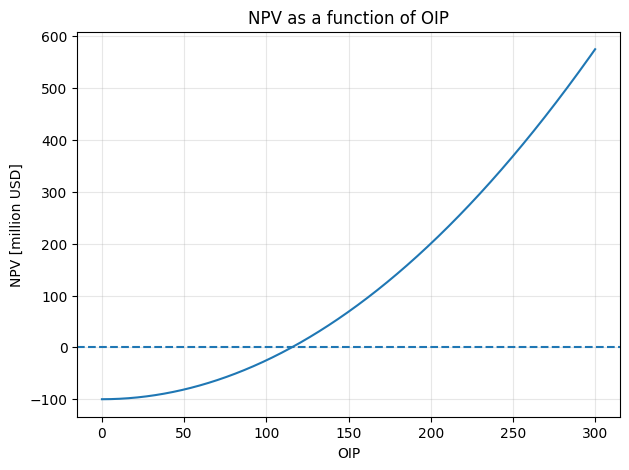

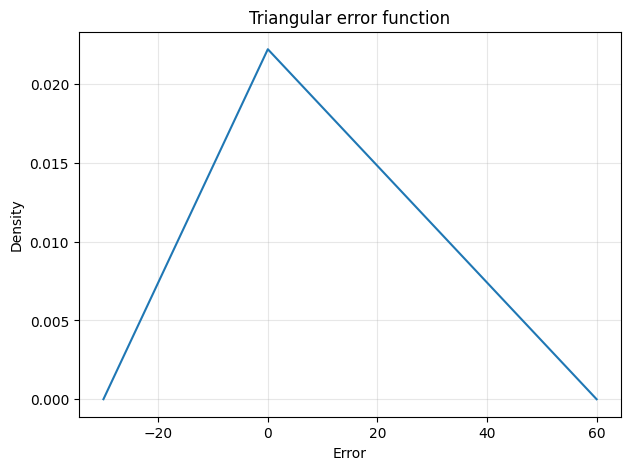

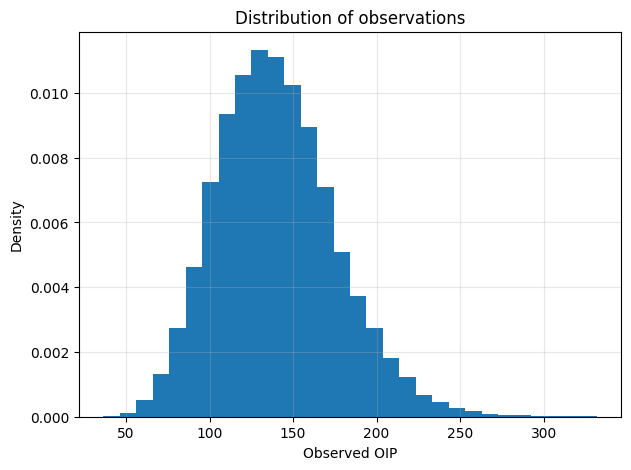

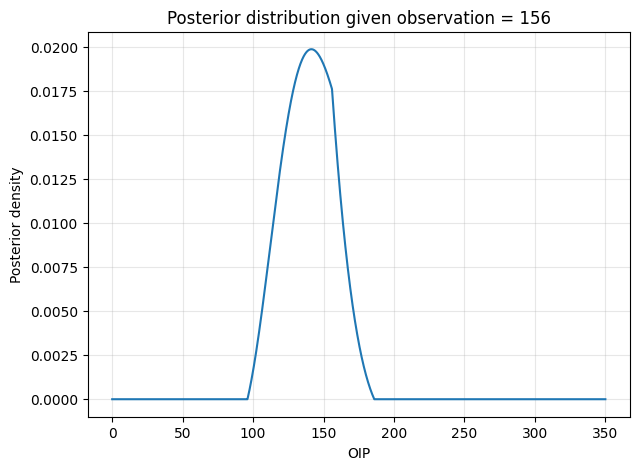

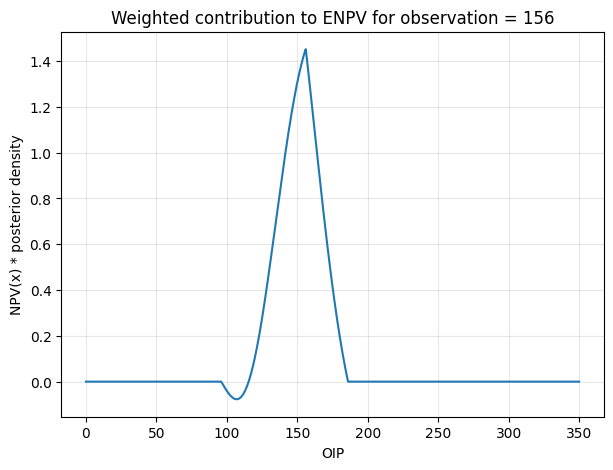

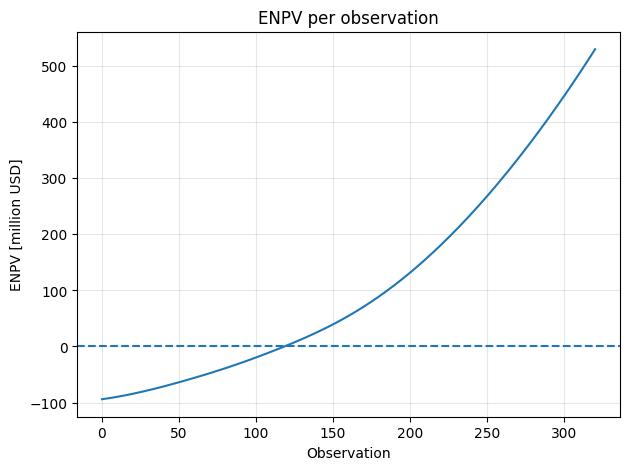

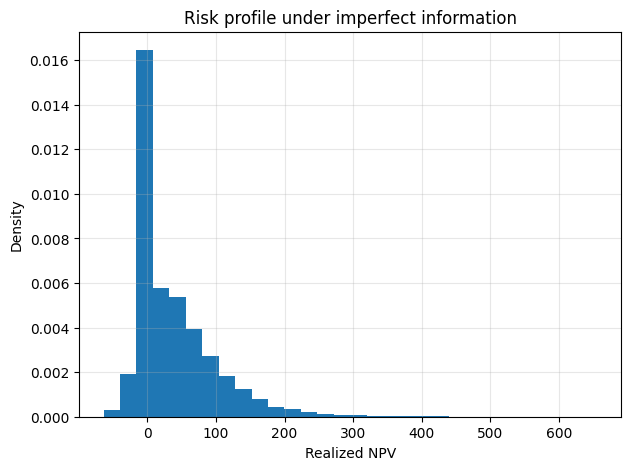

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, triang

# =========================================================
# Paper example:
# Prior OIP ~ Lognormal(mean=130, std=30)
# NPV(x) = -100 + 0.0075*x^2
# Error ~ Triangular(-30, 0, 60)
# Decision: develop if ENPV > 0, else do not develop
# =========================================================

# -----------------------------
# 1) Helper: convert arithmetic mean/std to lognormal params
# -----------------------------
def lognormal_params_from_mean_std(mean, std):
    """
    Convert arithmetic mean and standard deviation of X
    to parameters of ln(X) ~ N(mu, sigma^2).
    """
    variance = std**2
    sigma2 = np.log(1 + variance / mean**2)
    sigma = np.sqrt(sigma2)
    mu = np.log(mean) - 0.5 * sigma2
    return mu, sigma


# -----------------------------
# 2) Model definitions
# -----------------------------
MEAN_OIP = 130.0
STD_OIP = 30.0

mu_ln, sigma_ln = lognormal_params_from_mean_std(MEAN_OIP, STD_OIP)

# scipy lognorm parameterization:
# lognorm(s=sigma, scale=exp(mu))
prior_dist = lognorm(s=sigma_ln, scale=np.exp(mu_ln))

# Error distribution in paper: triangular from -30 to 60, mode 0
# scipy triang uses:
#   c = (mode-loc)/(scale)
#   loc = lower bound
#   scale = upper-lower
ERR_LOW = -30.0
ERR_MODE = 0.0
ERR_HIGH = 60.0

c = (ERR_MODE - ERR_LOW) / (ERR_HIGH - ERR_LOW)
error_dist = triang(c=c, loc=ERR_LOW, scale=(ERR_HIGH - ERR_LOW))


def npv_develop(x):
    """
    Field NPV function from paper.
    x = OIP
    returns NPV in million USD
    """
    return -100.0 + 0.0075 * x**2


def decision_from_enpv(enpv):
    """
    Develop if expected NPV > 0, otherwise do not develop.
    """
    return "develop" if enpv > 0 else "do_not_develop"


# -----------------------------
# 3) Base case: go now
# -----------------------------
def estimate_emv_go_now(n_samples=200_000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    x = prior_dist.rvs(size=n_samples, random_state=rng)
    npvs = npv_develop(x)

    emv_develop = np.mean(npvs)
    emv_do_not = 0.0

    best_emv = max(emv_develop, emv_do_not)
    best_decision = "develop" if emv_develop > 0 else "do_not_develop"

    return {
        "EMV_develop": emv_develop,
        "EMV_do_not_develop": emv_do_not,
        "EMV_go_now": best_emv,
        "best_decision": best_decision,
        "sampled_x": x,
        "sampled_npvs": npvs
    }


# -----------------------------
# 4) Perfect information
# -----------------------------
def estimate_emv_perfect_info(n_samples=200_000, random_seed=43):
    rng = np.random.default_rng(random_seed)
    x = prior_dist.rvs(size=n_samples, random_state=rng)
    npvs = npv_develop(x)

    # With perfect info:
    # if NPV(x) > 0 => develop, else don't develop
    payoff_with_perfect_info = np.maximum(npvs, 0.0)

    return {
        "EMV_perfect_info": np.mean(payoff_with_perfect_info),
        "payoff_samples": payoff_with_perfect_info,
        "x_samples": x
    }


# -----------------------------
# 5) Posterior on a grid using Bayes rule
# -----------------------------
def posterior_pdf_on_grid(y_obs, x_grid):
    """
    Posterior f(x|y) proportional to f(y|x) f(x)
    where y = x + e  =>  e = y - x
    """
    prior_pdf = prior_dist.pdf(x_grid)

    # likelihood f(y|x) = f_e(y-x)
    likelihood = error_dist.pdf(y_obs - x_grid)

    unnorm = prior_pdf * likelihood

    area = np.trapz(unnorm, x_grid)
    if area <= 0:
        posterior_pdf = np.zeros_like(x_grid)
    else:
        posterior_pdf = unnorm / area

    return posterior_pdf


def posterior_enpv_given_observation(y_obs, x_grid):
    """
    ENPV(develop | y_obs) = ∫ NPV(x) f(x|y_obs) dx
    ENPV(do not develop | y_obs) = 0
    """
    posterior_pdf = posterior_pdf_on_grid(y_obs, x_grid)
    npv_vals = npv_develop(x_grid)

    enpv_develop = np.trapz(npv_vals * posterior_pdf, x_grid)
    enpv_do_not = 0.0

    if enpv_develop > enpv_do_not:
        best_action = "develop"
        best_enpv = enpv_develop
    else:
        best_action = "do_not_develop"
        best_enpv = 0.0

    return {
        "posterior_pdf": posterior_pdf,
        "ENPV_develop": enpv_develop,
        "ENPV_do_not_develop": enpv_do_not,
        "best_action": best_action,
        "best_ENPV": best_enpv
    }


# -----------------------------
# 6) Imperfect information via nested MC
# -----------------------------
def estimate_emv_imperfect_info(
    outer_samples=50_000,
    x_grid=None,
    random_seed=44
):
    """
    Paper logic:
      1) sample true x from prior
      2) sample error e
      3) observed y = x + e
      4) build posterior f(x|y)
      5) choose best action based on posterior ENPV
      6) evaluate realized payoff using true x

    Realized payoff:
      - if choose develop => NPV(true x)
      - if choose do not develop => 0
    """
    rng = np.random.default_rng(random_seed)

    if x_grid is None:
        x_grid = np.linspace(1e-3, 350, 2500)

    true_x = prior_dist.rvs(size=outer_samples, random_state=rng)
    errors = error_dist.rvs(size=outer_samples, random_state=rng)
    y_obs = true_x + errors

    realized_payoffs = np.zeros(outer_samples)
    chosen_actions = []

    for i in range(outer_samples):
        result = posterior_enpv_given_observation(y_obs[i], x_grid)

        action = result["best_action"]
        chosen_actions.append(action)

        if action == "develop":
            realized_payoffs[i] = npv_develop(true_x[i])
        else:
            realized_payoffs[i] = 0.0

    emv_imperfect = np.mean(realized_payoffs)

    return {
        "EMV_imperfect_info": emv_imperfect,
        "realized_payoffs": realized_payoffs,
        "true_x": true_x,
        "y_obs": y_obs,
        "chosen_actions": np.array(chosen_actions)
    }


# -----------------------------
# 7) ENPV curve versus observation
# -----------------------------
def enpv_curve(observation_grid, x_grid):
    enpv_values = np.zeros_like(observation_grid, dtype=float)

    for i, y in enumerate(observation_grid):
        result = posterior_enpv_given_observation(y, x_grid)
        enpv_values[i] = result["ENPV_develop"]

    return enpv_values


# -----------------------------
# 8) Run all calculations
# -----------------------------
def main():
    x_grid = np.linspace(1e-3, 350, 3000)

    # Base case
    base = estimate_emv_go_now(n_samples=200_000, random_seed=42)

    # Perfect info
    perfect = estimate_emv_perfect_info(n_samples=200_000, random_seed=43)

    # Imperfect info
    imperfect = estimate_emv_imperfect_info(
        outer_samples=40_000,
        x_grid=x_grid,
        random_seed=44
    )

    emv_go_now = base["EMV_go_now"]
    emv_perfect = perfect["EMV_perfect_info"]
    emv_imperfect = imperfect["EMV_imperfect_info"]

    vopi = emv_perfect - emv_go_now
    voi_imperfect = emv_imperfect - emv_go_now

    print("=" * 60)
    print("RESULTS")
    print("=" * 60)
    print(f"EMV(go now)             = {emv_go_now:.3f}")
    print(f"Best decision now       = {base['best_decision']}")
    print(f"EMV(perfect info)       = {emv_perfect:.3f}")
    print(f"VOPI                    = {vopi:.3f}")
    print(f"EMV(imperfect info)     = {emv_imperfect:.3f}")
    print(f"VOI(imperfect)          = {voi_imperfect:.3f}")
    print("=" * 60)

    # Example posterior for observation 156 (shown in paper)
    y_example = 156.0
    post_example = posterior_enpv_given_observation(y_example, x_grid)
    posterior_pdf = post_example["posterior_pdf"]

    print(f"\nFor observation y = {y_example}:")
    print(f"ENPV(develop | y=156)   = {post_example['ENPV_develop']:.3f}")
    print(f"Best action             = {post_example['best_action']}")

    # Observation distribution by simulation
    obs_samples = imperfect["y_obs"]

    # ENPV per observation curve
    obs_grid = np.linspace(0, 320, 200)
    enpv_vals = enpv_curve(obs_grid, x_grid)

    # -------------------------
    # Plots
    # -------------------------
    plt.figure(figsize=(7, 5))
    xx = np.linspace(0.001, 300, 1000)
    plt.plot(xx, prior_dist.pdf(xx))
    plt.xlabel("OIP")
    plt.ylabel("Density")
    plt.title("Continuous prior distribution of OIP")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    npv_vals = npv_develop(xx)
    plt.plot(xx, npv_vals)
    plt.axhline(0, linestyle="--")
    plt.xlabel("OIP")
    plt.ylabel("NPV [million USD]")
    plt.title("NPV as a function of OIP")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    ee = np.linspace(ERR_LOW, ERR_HIGH, 1000)
    plt.plot(ee, error_dist.pdf(ee))
    plt.xlabel("Error")
    plt.ylabel("Density")
    plt.title("Triangular error function")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.hist(obs_samples, bins=30, density=True)
    plt.xlabel("Observed OIP")
    plt.ylabel("Density")
    plt.title("Distribution of observations")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(x_grid, posterior_pdf)
    plt.xlabel("OIP")
    plt.ylabel("Posterior density")
    plt.title("Posterior distribution given observation = 156")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(x_grid, npv_develop(x_grid) * posterior_pdf)
    plt.xlabel("OIP")
    plt.ylabel("NPV(x) * posterior density")
    plt.title("Weighted contribution to ENPV for observation = 156")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(obs_grid, enpv_vals)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Observation")
    plt.ylabel("ENPV [million USD]")
    plt.title("ENPV per observation")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.hist(imperfect["realized_payoffs"], bins=30, density=True)
    plt.xlabel("Realized NPV")
    plt.ylabel("Density")
    plt.title("Risk profile under imperfect information")
    plt.grid(alpha=0.3)
    plt.show()


if __name__ == "__main__":
    main()